# Hotel Review Intelligence Engine - Demo Notebook

**Expedia Group Campus Hackathon 2026 - Innovation Round**

This notebook loads the already-processed outputs from `pipeline.py`, `drift_analysis.py`, and `recommend.py`, and walks through the three core capabilities of the system:

1. Aspect-based sentiment scoring
2. Temporal / seasonal performance tracking
3. Personalized, evidence-based recommendations

No models are re-run here - this notebook is a fast, lightweight walkthrough of results already generated. Run `python pipeline.py`, `python drift_analysis.py`, and `python recommend.py` first if the files under `data/processed/` don't exist yet.

In [1]:
import pandas as pd
import json
from IPython.display import display, Image, Markdown

pd.set_option('display.max_colwidth', None)

## 1. Aspect-Based Sentiment — Raw Output

This is the output of `pipeline.py`: signed sentiment scores per hotel, per aspect, per month.

In [2]:
aspect_sentiment = pd.read_csv('data/processed/aspect_sentiment.csv')
print(f"Shape: {aspect_sentiment.shape}")
aspect_sentiment.head(10)

Shape: (9952, 5)


,hotel_id,aspect,year_month,avg_sentiment_score,review_count
0,H001,amenities,2024-01,0.000200,11
1,H001,amenities,2024-02,-0.058574,13
2,H001,amenities,2024-03,-0.176082,15
3,H001,amenities,2024-04,0.274760,10
4,H001,amenities,2024-05,0.251249,16
5,H001,amenities,2024-06,-0.065013,13
6,H001,amenities,2024-07,0.166710,11
7,H001,amenities,2024-08,-0.225830,9
8,H001,amenities,2024-09,0.060208,14
9,H001,amenities,2024-10,0.001969,11


### Quick sanity check: sentiment sign distribution

Confirms that both strongly positive and strongly negative scores are present - i.e. the model isn't defaulting to one label.

In [3]:
print("Score summary statistics:")
print(aspect_sentiment['avg_sentiment_score'].describe())
print(f"\nPositive-average rows: {(aspect_sentiment['avg_sentiment_score'] > 0).sum()}")
print(f"Negative-average rows: {(aspect_sentiment['avg_sentiment_score'] < 0).sum()}")

Score summary statistics:
count    9952.000000
mean        0.239226
std         0.773274
min        -0.999811
25%        -0.421925
50%         0.430448
75%         0.998994
max         0.999888
Name: avg_sentiment_score, dtype: float64

Positive-average rows: 6506
Negative-average rows: 3446


## 2. Temporal & Seasonal Performance Tracking

This is the output of `drift_analysis.py`: which hotel-aspect pairs are trending up, down, or stable, and whether any season stands out.

In [4]:
performance_summary = pd.read_csv('data/processed/hotel_performance_summary.csv')
print(f"Shape: {performance_summary.shape}")

print("\nTrend direction counts:")
print(performance_summary['trend_direction'].value_counts())

print("\nHotel-aspect pairs with a flagged anomalous season:")
print(performance_summary['flagged_season'].notna().sum(), "out of", len(performance_summary))

Shape: (483, 6)

Trend direction counts:
trend_direction
stable       356
declining     68
improving     59
Name: count, dtype: int64

Hotel-aspect pairs with a flagged anomalous season:
401 out of 483


In [5]:
# Show the strongest declining trends — these are the hotels/aspects most worth flagging
performance_summary.sort_values('trend_slope').head(10)

,hotel_id,aspect,trend_direction,trend_slope,flagged_season,deviation_magnitude
472,H118,location,declining,-0.063067,Summer,0.443711
412,H104,value,declining,-0.049493,Autumn,0.393262
124,H033,location,declining,-0.038857,Winter,0.181459
372,H094,value,declining,-0.032386,Summer,0.678929
197,H052,amenities,declining,-0.031534,Summer,0.235024
136,H036,location,declining,-0.030267,Winter,1.382492
303,H078,value,declining,-0.030150,Winter,0.327554
471,H118,amenities,declining,-0.029174,Winter,0.205466
123,H033,amenities,declining,-0.028315,Summer,1.115456
222,H058,location,declining,-0.027721,Autumn,0.799722


### Sample trend visualization

Pre-generated chart from `drift_analysis.py` showing a hotel's aspect sentiment over time.

Available plots: ['H118_location_trend.png']


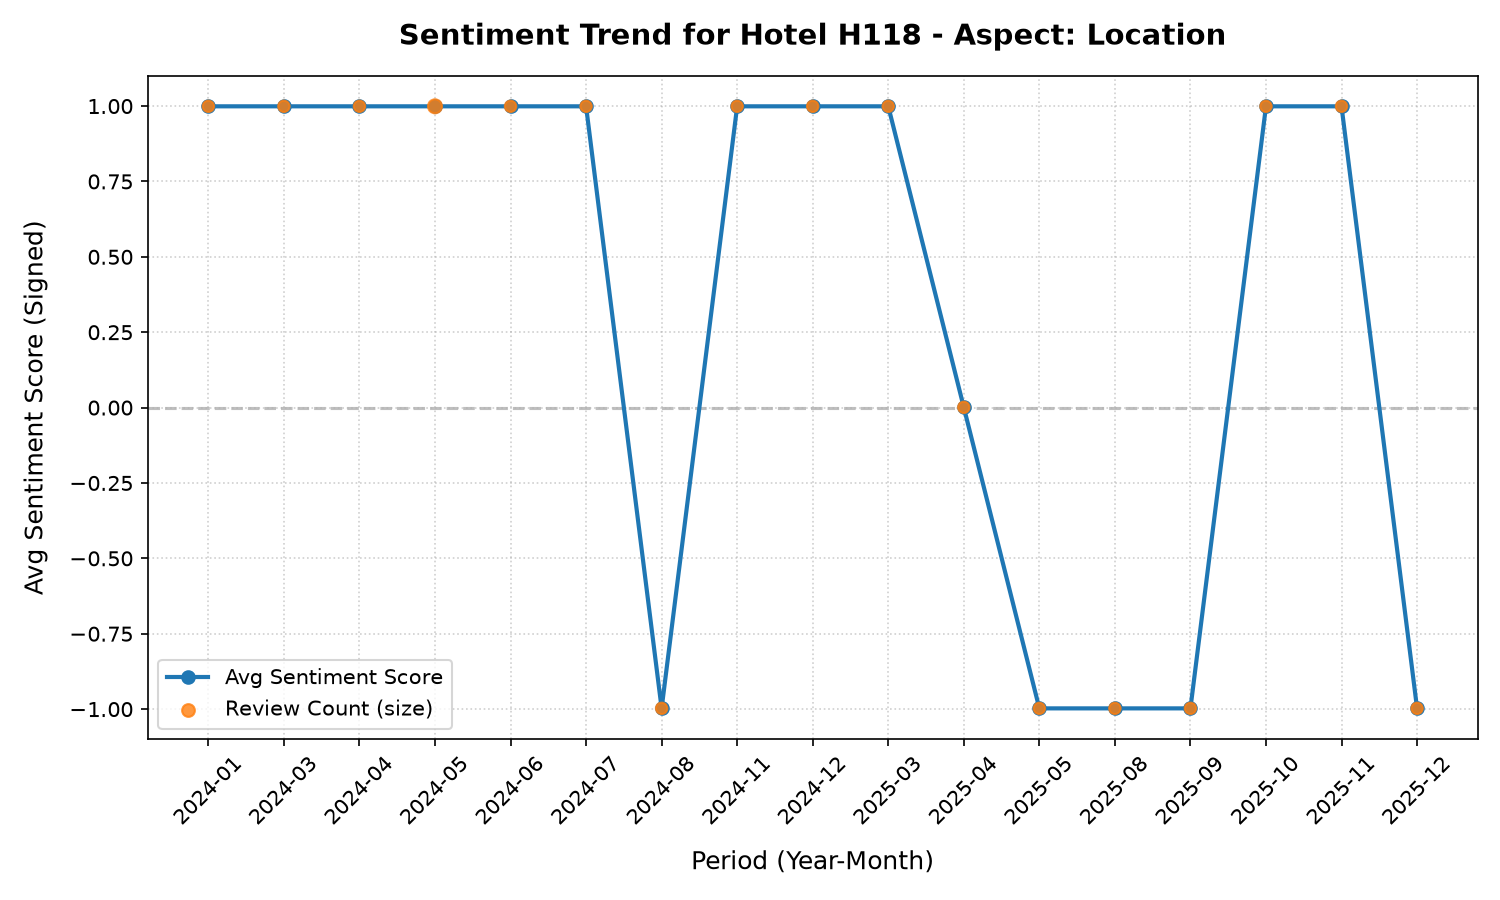

In [6]:
import os

plots_dir = 'data/processed/plots'
available_plots = os.listdir(plots_dir) if os.path.exists(plots_dir) else []
print("Available plots:", available_plots)

if available_plots:
    display(Image(filename=os.path.join(plots_dir, available_plots[0])))

## 3. Personalized, Evidence-Based Recommendations

This is the output of `recommend.py`: for each of the 50 user profiles, the top 5 recommended hotels with relevance scores and plain-language evidence.

In [7]:
with open('data/processed/recommendations.json') as f:
    recommendations = json.load(f)

print(f"Total profiles: {len(recommendations)}")
print(f"Sample profile IDs: {list(recommendations.keys())[:5]}")

Total profiles: 50
Sample profile IDs: ['P01', 'P02', 'P03', 'P04', 'P05']


### Pick a profile to inspect

Change `profile_id` below to explore a different persona (P01 through P50).

In [8]:
profile_id = "P01"

profile_data = recommendations[profile_id]

print(f"Profile: {profile_id}")
print(f"Archetype: {profile_data['archetype']}")
print(f"Desired dimensions: {profile_data['desired_dims']}")
print("\nTop 5 recommended hotels:\n")

top_hotels_df = pd.DataFrame(profile_data['top_hotels'])
top_hotels_df

Profile: P01
Archetype: solo_female_local
Desired dimensions: ['local_culture', 'location_central', 'safety']

Top 5 recommended hotels:



,rank,hotel_id,hotel_name,relevance_score,evidence
0,1,H014,"The Meridian Plaza, London",0.9999,"Strong match on: location (1.00), amenities (0.54)"
1,2,H027,"Hotel Magnolia, Cape Town",0.9999,"Strong match on: location (1.00), service (0.44)"
2,3,H106,"The Park Aurora, Mexico City",0.9999,"Strong match on: location (1.00), amenities (0.96)"
3,4,H051,"Casa Harbour, Istanbul",0.9999,"Strong match on: location (1.00), amenities (0.45)"
4,5,H098,"The Royal Plaza, Mumbai",0.9999,Strong match on: location (1.00)


### Readable version - recommendation card style

In [9]:
md_output = f"### Recommendations for `{profile_id}` — *{profile_data['archetype']}*\n\n"
md_output += f"**Priorities:** {', '.join(profile_data['desired_dims'])}\n\n"

for hotel in profile_data['top_hotels']:
    md_output += (
        f"**#{hotel['rank']} — {hotel['hotel_name']}** "
        f"(relevance: {hotel['relevance_score']})\n\n"
        f"> {hotel['evidence']}\n\n"
    )

display(Markdown(md_output))

### Recommendations for `P01` — *solo_female_local*

**Priorities:** local_culture, location_central, safety

**#1 — The Meridian Plaza, London** (relevance: 0.9999)

> Strong match on: location (1.00), amenities (0.54)

**#2 — Hotel Magnolia, Cape Town** (relevance: 0.9999)

> Strong match on: location (1.00), service (0.44)

**#3 — The Park Aurora, Mexico City** (relevance: 0.9999)

> Strong match on: location (1.00), amenities (0.96)

**#4 — Casa Harbour, Istanbul** (relevance: 0.9999)

> Strong match on: location (1.00), amenities (0.45)

**#5 — The Royal Plaza, Mumbai** (relevance: 0.9999)

> Strong match on: location (1.00)



### Compare two different personas

This demonstrates that recommendations genuinely differ based on inferred priorities - e.g. a corporate traveler vs. a family traveler should surface different top hotels.

In [10]:
compare_ids = ["P02", "P03"]  # corporate road-warrior vs. family with toddlers

for pid in compare_ids:
    data = recommendations[pid]
    print(f"\n=== {pid} - {data['archetype']} ===")
    print(f"Priorities: {data['desired_dims']}")
    print("Top 3 hotels:")
    for hotel in data['top_hotels'][:3]:
        print(f"  #{hotel['rank']} {hotel['hotel_name']} (score: {hotel['relevance_score']}) - {hotel['evidence']}")


=== P02 - corporate_budget_location ===
Priorities: ['location_central', 'business_connectivity', 'budget_value']
Top 3 hotels:
  #1 Hotel Belmont, Mexico City (score: 0.925) - Strong match on: location (1.00), value (0.80)
  #2 The Park Continental, Lima (score: 0.6805) - Strong match on: location (0.82), value (0.79)
  #3 The Belmont, Bangkok (score: 0.6661) - Strong match on: location (1.00), amenities (1.00)

=== P03 - family_budget ===
Priorities: ['family_friendly', 'budget_value']
Top 3 hotels:
  #1 The Boulevard Verde, Lisbon (score: 0.9231) - Strong match on: amenities (0.92), value (0.89)
  #2 The Belmont, Seoul (score: 0.8799) - Strong match on: amenities (0.91), value (0.79)
  #3 Casa Atrium, Seoul (score: 0.832) - Strong match on: amenities (1.00), service (1.00)


## Summary

This notebook demonstrates the end-to-end output of the Hotel Review Intelligence Engine:

- **Aspect-level sentiment** extracted from 50,000 reviews across 5 aspects
- **Temporal/seasonal performance tracking** per hotel and aspect
- **Personalized, evidence-based top-5 recommendations** for 50 distinct traveler profiles

See `README.md` for full architecture details, key dataset findings, assumptions, and limitations.